In [8]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
from np_chunker import conll_reader

In [13]:
reader= conll_reader.ConllReader()

# doc_id = htb:15
# doc_range = 5686-5773
# sent_id = 485
# text = הקהל איתר סוף סוף ערבי ויהודים חבטו בו עד זוב דם.


In [14]:
def count_docs(input_file):
    text = Path(input_file).resolve().read_text(encoding="utf-8").strip()
    docs = []
    for chunk in text.split("\n\n"):
        lines = chunk.split("\n")
        docs.append(lines[0].split("=")[-1].strip())
    return Counter(docs)

In [15]:
train = count_docs("corpus/new_htb/he_htb-ud-doc2-train.conllu")
dev = count_docs("corpus/new_htb/he_htb-ud-doc2-dev.conllu")
test = count_docs("corpus/new_htb/he_htb-ud-doc2-test.conllu")

In [16]:
htb = train + dev + test

In [17]:
print(f"num of docs: {len(htb)}")

num of docs: 248


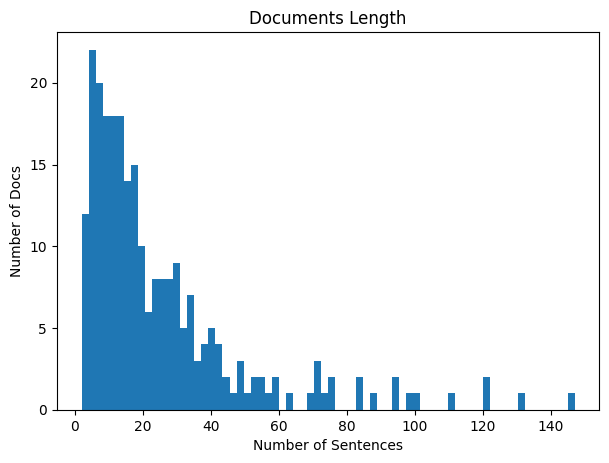

In [33]:
sents_count = htb.values()
plt.rcParams.update({'figure.figsize':(7,5), 'figure.dpi':100})
plt.hist(htb.values(), bins=70)
plt.gca().set(title='Documents Length', ylabel='Number of Docs', xlabel="Number of Sentences");


In [21]:
import numpy as np

In [28]:
count = np.array(list(sents_count))

In [34]:
print(count.mean())
print(np.median(count))
print(count.std())
print(count.var())

25.06451612903226
17.0
24.505016581693937
600.4958376690948


In [45]:
count[np.where(count >100 )]

array([147, 131, 111, 101, 121, 122])